# Toy 1D manifold

Loads the score net trained in `01_train_score.ipynb` and runs FR-guided sampling through (`driver.guided_reverse_loop`). 

Compares:
- **guidance method**: k-NN Fisher-Rao energy (`basic_fr.py`) vs. score-divergence energy (`score_divergence.py`) (algo 2 in the manuscript).
- **jacobian**: none (full ambient R^2) vs. analytic tangent projection (ground-truth tangent of `y = 0.6 sin(2x)`).
- **guidance time-window**: varying the guidance penalty window.
- **penalty strength** `lam`: swept over several values.
- **gradience clipping**: this seems to affect the performance strongly and I could not deciper it fully yet.

**Metrics** (per user spec):
- **Memorization**: per-sample ratio `dist_to_nearest_atom / dist_to_second_nearest_atom`; a sample counts as memorized if this ratio is belor a threshold.
-  `mem_ratio` = fraction of samples memorized.
- **Fidelity**: mean squared distance to the manifold (`fidelity_mse`).

In [1]:
import os, sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../../src"))
from guidance import driver, basic_fr, score_divergence, bayesian_fr

REGIME = "normal"   # "normal" or "overtrained" - selects checkpoints/score_{REGIME}_N{N}.pt
N = int(os.environ.get("N_DATA", 30)) #other saved N options - 10, 20, 30, 50, 100
TAG = f"{REGIME}_N{N}"
ckpt = torch.load(f"checkpoints/score_{TAG}.pt", weights_only=False)
train_config = ckpt["config"]
d, device = train_config["d"], train_config["device"]
X_target = ckpt["X_target"].to(device)
u_target = ckpt["u_target"].to(device)

# All of THIS notebook's own outputs (figs, csv) go here, one folder per (N, REGIME) combo -- change
# either above and a fresh folder is created automatically, instead of everything piling up flat in
# checkpoints/ distinguished only by a filename suffix. The score/jacnet checkpoint LOAD path above is
# unaffected (that's 01_train_score.ipynb's output, not this notebook's).
OUT_DIR = f"checkpoints/N{N}-{REGIME}"
os.makedirs(OUT_DIR, exist_ok=True)

print(f"regime={REGIME}  N={N}  d={d}, device={device}, N_data={X_target.shape[0]}, iters={train_config['iters']}")
print(f"outputs -> {OUT_DIR}/")

regime=normal  N=30  d=2, device=cpu, N_data=30, iters=50000
outputs -> checkpoints/N30-normal/


In [2]:
class ScoreNet(nn.Module):
    def __init__(self, d, hidden, depth):
        super().__init__()
        self.input_proj = nn.Linear(d + 1, hidden)
        self.layers = nn.ModuleList([nn.Linear(hidden, hidden) for _ in range(depth * 2)])
        self.output_proj = nn.Linear(hidden, d)

    def forward(self, x, t):
        h = F.silu(self.input_proj(torch.cat([x, t[:, None]], dim=-1)))
        for i in range(0, len(self.layers), 2):
            r = F.silu(self.layers[i](h))
            r = self.layers[i + 1](r)
            h = h + r
        return self.output_proj(h)

net = ScoreNet(d, train_config["hidden"], train_config["depth"]).to(device)
net.load_state_dict(ckpt["net_state"])
net.eval()
print("Loaded score net.")

Loaded score net.


In [3]:
config = {
    "beta_min": train_config["beta_min"], "beta_max": train_config["beta_max"], "T": train_config["T"],
    "n_steps": 1000,
    "n_samples": 200,
    "seed": 10,
    "k_neighbors": 3,
    "r_probes": 5,
    "ell": 1,
    "mem_ratio_threshold": 1 / 3,
    "lambdas": [0.01, 0.1, 0.5],

    "grad_clips": [1000, 10000, 100000],
}


windows = {
    "throughout": (0.0, 1),
    "early": (0.0, 0.25),
    #"early_mid": (0.0, 0.5),
    "mid": (0.25, 0.75),
    #"mid_late": (0.5, 1.0),
    "late": (0.75, 1),
    #"very_late": (0.85, 0.95),
    #"very_early": (0, 0.15)
}

# Schedule (VP-linear here; swap these four to change schedule -- everything else reads
# only beta/alpha_bar/sigma2/g2, never beta_min/beta_max directly).
def beta(t):
    return config["beta_min"] + t * (config["beta_max"] - config["beta_min"])

def alpha_bar(t):
    return torch.exp(-(config["beta_min"] * t + 0.5 * (config["beta_max"] - config["beta_min"]) * t ** 2))

def sigma2(t):
    return (1 - alpha_bar(t)).clamp(min=1e-4)

def g2(t):
    return beta(t)   # forward SDE's diffusion coefficient squared -- what step_scale_fn needs

## Wire up the generic interface for sampling and guidance

`base_step_fn(z_t, step_idx) -> z_{t-1}` is the plain reverse SDE step; `y_fn(z_t) -> y` is the denoiser
$D_t(z_t) = (z_t - \sqrt{1-\bar\alpha_t}\,\hat\epsilon)/\sqrt{\bar\alpha_t}$.

In [4]:
n_steps = config["n_steps"]
dt = config["T"] / n_steps
t_vec_holder = {"t": None}

def make_base_step_fn():
    def base_step_fn(z_t, step_idx):
        k = n_steps - step_idx
        t_vec = torch.full((z_t.shape[0],), (k + 1) * dt, device=device)
        t_vec_holder["t"] = t_vec
        with torch.no_grad():
            eps_hat = net(z_t, t_vec)
            score = -eps_hat / sigma2(t_vec)[:, None].sqrt()
            drift = -0.5 * beta(t_vec)[:, None] * z_t - beta(t_vec)[:, None] * score
            noise = beta(t_vec)[:, None].sqrt() * torch.randn_like(z_t) if k > 0 else 0
        return z_t - drift * dt + noise * dt ** 0.5
    return base_step_fn

def y_fn(z_t):
    t_vec = t_vec_holder["t"]
    eps_hat = net(z_t, t_vec)
    a = alpha_bar(t_vec)
    return (z_t - (1 - a)[:, None].sqrt() * eps_hat) / a[:, None].sqrt()

def step_scale_fn(step_idx):
    # guidance must scale like g(t)^2 * dt (form the reverse-SDE derivation)
    k = n_steps - step_idx
    t_vec = torch.full((config["n_samples"],), (k + 1) * dt, device=device)
    return g2(t_vec)[:, None] * dt

## Guidance energies

**k-NN Fisher-Rao** (`basic_fr.fisher_rao_energy`, the "Basic" algorithm variant): `beta_t` is pinned to `sigma_t^2` (the schedule's own noise variance), *not* a free hyperparameter -- unlike the old `preliminary/fisher_rao_guidance_so(n).ipynb` notebook's `config["beta_fr"]`, which had to be hand-tuned and is exactly the "how do we choose temperature" pain point. This module sidesteps that by construction.

**Score-divergence** (`score_divergence.make_score_div_energy_fn`): `I(y) = trace(grad_y s_theta(y,t)) + d/sigma_t^2`, estimated with `r_probes` Hutchinson probes -- no atom index, no temperature parameter of any kind.

In [5]:
index = basic_fr.build_flat_index(X_target)

def make_knn_energy_fn():
    def energy_fn(y):
        with torch.no_grad():
            neighbors, _ = basic_fr.ann_query(index, y, config["k_neighbors"])
        I, _, _ = basic_fr.fisher_rao_energy(y, neighbors, sigma2(t_vec_holder["t"]))
        return I
    return energy_fn

def score_fn(y):
    t_vec = t_vec_holder["t"]
    eps_hat = net(y, t_vec)
    return -eps_hat / sigma2(t_vec)[:, None].sqrt()

def sigma2_fn():
    return sigma2(t_vec_holder["t"])

def d_fn():
    return d

def make_score_divergence_energy_fn():
    return score_divergence.make_score_div_energy_fn(score_fn, sigma2_fn, d_fn, r=config["r_probes"])

ENERGY_FACTORIES = {
    "basic_fr": make_knn_energy_fn,
    "score_divergence": make_score_divergence_energy_fn,
    #add the Bayesian FR one here.
}

# Tangent-projected counterparts: energy_fn(y, P) -> I, restricted to tangent directions by
# construction (see driver.projected_guidance_grad) rather than only reprojecting a downstream
# gradient. k=1 for score-divergence's flat-Gaussian correction term since the toy manifold's
# analytic tangent (below) is rank 1 by construction.
def make_knn_projected_energy_fn():
    return basic_fr.make_knn_projected_energy_fn(index, config["k_neighbors"], lambda: sigma2(t_vec_holder["t"]))

def make_score_divergence_projected_energy_fn():
    return score_divergence.make_score_div_projected_energy_fn(score_fn, sigma2_fn, k_fn=lambda: 1, r=config["r_probes"])

PROJECTED_ENERGY_FACTORIES = {
    "basic_fr": make_knn_projected_energy_fn,
    "score_divergence": make_score_divergence_projected_energy_fn,
}

## Analytic tangent Jacobian

Ground-truth tangent of `y = 0.6 sin(2x)`, evaluated at the x-coordinate of `y` itself. Rank 1 by construction (the manifold
is 1-D in this R^2 ambient space), so this builds `projector_fn(y) -> P` directly rather than going through
`driver.make_projector_fn`'s eigendecomposition (in `experiments/so_n/03_fr_guidance.ipynb`, a
learned Jacobian and an explicit tangent-dimension `k` are actually needed). `P` feeds both the projected
energy (`PROJECTED_ENERGY_FACTORIES`, restricting `I` itself to tangent directions) and its gradient
(`driver.projected_guidance_grad`, computed directly in y-space -- no chain through the denoiser).

Defined here (before the diagnostic below) so the diagnostic can plot projected gradient norms too.

In [6]:
def tangent_vec_from_u(u):
    t = torch.stack([torch.ones_like(u), 1.2 * torch.cos(2 * u)], dim=-1)
    return t / t.norm(dim=-1, keepdim=True)

def analytic_tangent_projector(y):
    u = y[:, 0].clamp(-3.2, 3.2)
    t = tangent_vec_from_u(u)          # [B, 2]
    return torch.einsum("bi,bj->bij", t, t)

JACOBIANS = {
    "unprojected": None,
    "projected": analytic_tangent_projector,
}

def make_guidance_fn(method, jacobian_name, grad_clip):
    projector_fn = JACOBIANS[jacobian_name]
    if projector_fn is None:
        energy_fn = ENERGY_FACTORIES[method]()
        return driver.make_autograd_guidance_fn(y_fn, energy_fn, target_range=None, grad_clip=grad_clip)
    energy_fn = PROJECTED_ENERGY_FACTORIES[method]()
    return driver.make_projected_guidance_fn(
        y_fn, energy_fn, projector_fn, target_range=None, grad_clip=grad_clip)

## Diagnostic: raw guidance gradient scale vs `t` (before clipping)

`basic_fr`'s energy divides by `beta_t**2 = sigma_t**4` (`src/guidance/basic_fr.py`'s `fisher_rao_energy`), so
`I(y)` should blow up as `t -> 0` (`sigma_t -> 0`, approaching clean data),

Computed along a single unguided trajectory (so the diagnostic isn't confounded by guidance already perturbing
the path) via `driver.guidance_grad(..., grad_clip=None)` (unprojected, left panel) and
`driver.projected_guidance_grad(..., grad_clip=None)` (projected onto the analytic tangent, right panel) at
every step, for both energies. Separate panels + separate color sets (blue/orange unprojected vs.
green/red projected) since the two are different quantities -- restricting to tangent directions changes what
`I` and its gradient actually measure, not just how large they are.

**`||score(z_t)||` reference curve** (dashed black, both panels): shows which term actually dominates the
per-step update. The base reverse step's drift contains `-beta(t)*score` and the guidance correction is
`lam*step_scale_fn(t)*grad = lam*beta(t)*dt*grad` (since `step_scale_fn = g2(t)*dt = beta(t)*dt`) -- the
`beta(t)*dt` prefactor is shared by both terms, so comparing raw `||grad||` to raw `||score||` directly (no
extra scaling needed) tells you the guidance-to-score ratio is approximately `lam * ||grad|| / ||score||`.</cell id="3cf50e00">


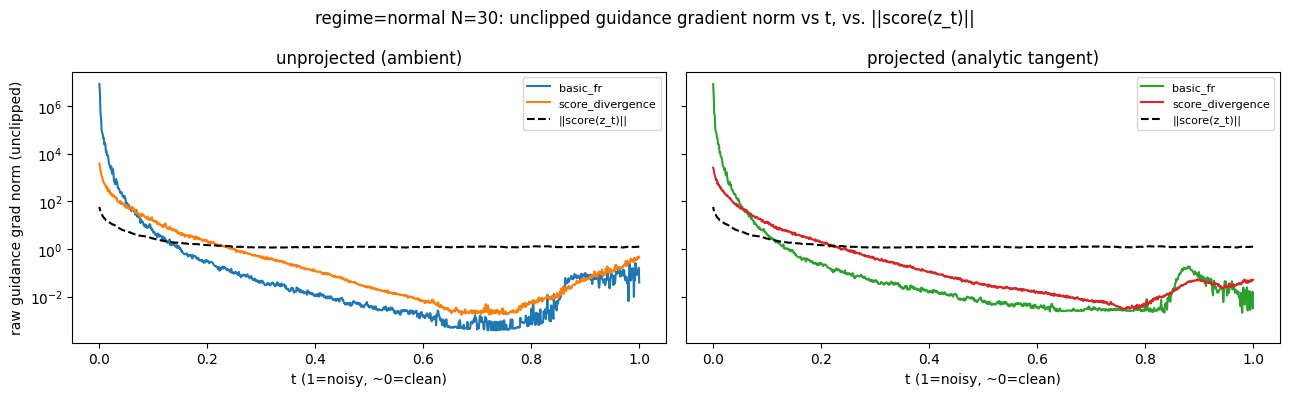

In [7]:
torch.manual_seed(config["seed"])
z = torch.randn(config["n_samples"], d, device=device)
base_step_fn = make_base_step_fn()
diag_energy_fns = {"basic_fr": make_knn_energy_fn(), "score_divergence": make_score_divergence_energy_fn()}
diag_projected_energy_fns = {"basic_fr": make_knn_projected_energy_fn(), "score_divergence": make_score_divergence_projected_energy_fn()}

diag_rows = []
score_norm_rows = []
for step_idx in range(1, n_steps + 1):
    z_next = base_step_fn(z, step_idx)   # also sets t_vec_holder["t"] for this step
    t_val = t_vec_holder["t"][0].item()
    sigma2_val = sigma2(t_vec_holder["t"])[0].item()
    with torch.no_grad():
        score = -net(z, t_vec_holder["t"]) / sigma2(t_vec_holder["t"])[:, None].sqrt()
    score_norm_rows.append({"step_idx": step_idx, "t": t_val, "score_norm_mean": score.norm(dim=-1).mean().item()})
    for name, energy_fn in diag_energy_fns.items():
        grad, _, _ = driver.guidance_grad(y_fn, z, energy_fn, target_range=None, grad_clip=None)
        gnorm = grad.norm(dim=-1)
        diag_rows.append({"step_idx": step_idx, "t": t_val, "sigma2": sigma2_val, "method": name, "projected": False,
                           "grad_norm_mean": gnorm.mean().item(), "grad_norm_max": gnorm.max().item()})
    for name, energy_fn in diag_projected_energy_fns.items():
        grad, _, _ = driver.projected_guidance_grad(y_fn, z, energy_fn, analytic_tangent_projector, target_range=None, grad_clip=None)
        gnorm = grad.norm(dim=-1)
        diag_rows.append({"step_idx": step_idx, "t": t_val, "sigma2": sigma2_val, "method": name, "projected": True,
                           "grad_norm_mean": gnorm.mean().item(), "grad_norm_max": gnorm.max().item()})
    z = z_next

diag_df = pd.DataFrame(diag_rows)
score_norm_df = pd.DataFrame(score_norm_rows)

UNPROJ_COLORS = {"basic_fr": "tab:blue", "score_divergence": "tab:orange"}
PROJ_COLORS = {"basic_fr": "tab:green", "score_divergence": "tab:red"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True, sharey=True)
for name, sub in diag_df[~diag_df["projected"]].groupby("method"):
    axes[0].plot(sub["t"], sub["grad_norm_mean"], label=name, color=UNPROJ_COLORS[name])
for name, sub in diag_df[diag_df["projected"]].groupby("method"):
    axes[1].plot(sub["t"], sub["grad_norm_mean"], label=name, color=PROJ_COLORS[name])

for ax, title in zip(axes, ["unprojected (ambient)", "projected (analytic tangent)"]):
    ax.plot(score_norm_df["t"], score_norm_df["score_norm_mean"], "--", color="black", label="||score(z_t)||")
    ax.set_xlabel("t (1=noisy, ~0=clean)"); ax.set_yscale("log"); ax.invert_xaxis()
    ax.set_title(title); ax.legend(fontsize=8)
axes[0].set_ylabel("raw guidance grad norm (unclipped)")
fig.suptitle(f"regime={REGIME} N={N}: unclipped guidance gradient norm vs t, vs. ||score(z_t)||")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/grad_norm_vs_t.png", dpi=120); plt.show()

## Metrics

- `mem_ratio`: fraction of samples with `dist(nearest atom) / dist(2nd-nearest atom) < mem_ratio_threshold`.
- `fidelity_mse`: mean squared distance to the true manifold curve (found by scanning the curve densely),
  computed **only over samples classified as NOT memorized**. A memorized sample already sits on (or
  essentially on) the manifold near a training atom, so folding it into the average would reward
  memorization instead of measuring whether guidance distorts the rest of the distribution -- `NaN` (not
  `0`) if every sample in a config is memorized, so that case doesn't get misread as "perfect fidelity"
  (pandas' `sort_values`/`idxmin` skip `NaN` by default, so such a config just won't win on this axis).

In [8]:
u_scan = torch.linspace(-4.0, 4.0, 4000, device=device)
curve_scan = torch.stack([u_scan, 0.6 * torch.sin(2 * u_scan)], dim=-1)   # [S, 2]

def dist_to_manifold(X):
    return torch.cdist(X, curve_scan).min(dim=1).values

def is_memorized(X, atoms, thresh):
    d2 = torch.cdist(X, atoms)
    top2 = torch.topk(d2, 2, largest=False, dim=1).values   # [B, 2], ascending
    ratio = top2[:, 0] / top2[:, 1].clamp(min=1e-8)
    return ratio.lt(thresh)

def evaluate(X):
    mem = is_memorized(X, X_target, config["mem_ratio_threshold"])
    unmem = ~mem
    fidelity = dist_to_manifold(X[unmem]).pow(2).mean().item() if unmem.any() else float("nan")
    return {
        "mem_ratio": mem.float().mean().item(),
        "fidelity_mse": fidelity,
    }

In [9]:
def run_condition(guidance_fn, lam, progress_lo, progress_hi):
    torch.manual_seed(config["seed"])
    z_init = torch.randn(config["n_samples"], d, device=device)
    if guidance_fn is None:
        x = z_init
        base_step_fn = make_base_step_fn()
        with torch.no_grad():
            for step_idx in range(1, n_steps + 1):
                x = base_step_fn(x, step_idx)
        return x.detach()
    z_final, _ = driver.guided_reverse_loop(
        z_init, n_steps, make_base_step_fn(), guidance_fn,
        progress_lo=progress_lo, progress_hi=progress_hi, ell=config["ell"], lam=lam,
        step_scale_fn=step_scale_fn)
    return z_final.detach()

X_unguided = run_condition(None, 0.0, 0.0, 1.0)
baseline = {"method": "unguided", "jacobian": "unprojected", "window": "n/a", "grad_clip": 0.0, "lam": 0.0, **evaluate(X_unguided)}
print(baseline)

{'method': 'unguided', 'jacobian': 'unprojected', 'window': 'n/a', 'grad_clip': 0.0, 'lam': 0.0, 'mem_ratio': 0.33000001311302185, 'fidelity_mse': 0.000818840169813484}


## Full sweep: method x jacobian x window x lambda

In [10]:
rows = [baseline]
samples_cache = {("unguided", "unprojected", "n/a", 0.0, 0.0): X_unguided}

for method in ENERGY_FACTORIES:
    for jacobian_name, jacobian_fn in JACOBIANS.items():
        for window_name, (progress_lo, progress_hi) in windows.items():
            for grad_clip in config["grad_clips"]:
                guidance_fn = make_guidance_fn(method, jacobian_name, grad_clip)
                for lam in config["lambdas"]:
                    X = run_condition(guidance_fn, lam, progress_lo, progress_hi)
                    row = {"method": method, "jacobian": jacobian_name, "window": window_name,
                           "grad_clip": grad_clip, "lam": lam, **evaluate(X)}
                    rows.append(row)
                    samples_cache[(method, jacobian_name, window_name, grad_clip, lam)] = X

df = pd.DataFrame(rows)
df["grad_clip"] = df["grad_clip"].fillna(0.0)
print(f"{len(df)} configs run.")
df.to_csv(f"{OUT_DIR}/fr_sweep_results.csv", index=False)
df.sort_values(["method", "jacobian", "window", "grad_clip", "lam"])

145 configs run.


,method,jacobian,window,grad_clip,lam,mem_ratio,fidelity_mse
46,basic_fr,projected,early,1000.0,0.01,0.330,0.000819
47,basic_fr,projected,early,1000.0,0.10,0.330,0.000820
48,basic_fr,projected,early,1000.0,0.50,0.335,0.000832
49,basic_fr,projected,early,10000.0,0.01,0.330,0.000819
50,basic_fr,projected,early,10000.0,0.10,0.330,0.000820
...,...,...,...,...,...,...,...
78,score_divergence,unprojected,throughout,10000.0,0.50,0.025,0.135969
79,score_divergence,unprojected,throughout,100000.0,0.01,0.305,0.000748
80,score_divergence,unprojected,throughout,100000.0,0.10,0.170,0.023723
81,score_divergence,unprojected,throughout,100000.0,0.50,0.025,0.134479


## Combined error and ranking

Fidelity and memorization live on very different scales (`fidelity_mse` ~1e-4-1e-1, `mem_ratio` in [0,1]), so a
raw sum isn't meaningful. Instead normalize each by the unguided baseline's value and add:

`combined_error = fidelity_mse / baseline_fidelity_mse + mem_ratio / baseline_mem_ratio`

A value of 2.0 means "no change from unguided on either axis"; lower is better on both; a config that only wins
on one axis at the other's expense won't look artificially good.

In [11]:
df["fidelity_rel"] = df["fidelity_mse"] / baseline["fidelity_mse"]
df["mem_rel"] = df["mem_ratio"] / baseline["mem_ratio"]
df["combined_error"] = df["fidelity_rel"] * 0.01 + df["mem_rel"] 
df.to_csv(f"{OUT_DIR}/fr_sweep_results.csv", index=False)

guided = df[df["method"] != "unguided"]

print(f"regime={REGIME} N={N}  baseline combined_error = {2.0:.3f} (fidelity_rel=1.0 + mem_rel=1.0)\n")
print("Top 15 configs by combined_error (lower is better):")
top = guided.sort_values("combined_error").head(15)
pd.set_option("display.width", 200)
print(top[["method", "jacobian", "window", "grad_clip", "lam", "mem_ratio", "fidelity_mse", "combined_error"]].to_string(index=False))

regime=normal N=30  baseline combined_error = 2.000 (fidelity_rel=1.0 + mem_rel=1.0)

Top 15 configs by combined_error (lower is better):
          method    jacobian     window  grad_clip  lam  mem_ratio  fidelity_mse  combined_error
        basic_fr   projected       late     1000.0 0.10      0.030      0.000686        0.099291
        basic_fr   projected throughout     1000.0 0.10      0.035      0.000705        0.114668
        basic_fr unprojected       late     1000.0 0.10      0.060      0.000718        0.190590
        basic_fr unprojected throughout     1000.0 0.10      0.065      0.000728        0.205866
        basic_fr unprojected       late    10000.0 0.01      0.085      0.000725        0.266425
        basic_fr unprojected throughout    10000.0 0.01      0.100      0.000691        0.311472
        basic_fr   projected throughout    10000.0 0.01      0.105      0.000725        0.327040
        basic_fr   projected       late    10000.0 0.01      0.120      0.000745      

In [12]:
print("Best achievable combined_error per (method, jacobian) i.e. best case over all windows/grad_clip/lam:\n")
best_per_method = guided.loc[guided.groupby(["method", "jacobian"])["combined_error"].idxmin()]
best_per_method = best_per_method.sort_values("combined_error")
print(best_per_method[["method", "jacobian", "window", "grad_clip", "lam", "mem_ratio", "fidelity_mse", "combined_error"]].to_string(index=False))

print("\nMedian combined_error per (method, jacobian), across all swept windows/grad_clip/lam"
      " -- how forgiving the method is to hyperparameter choice, not just its best case:\n")
robustness = guided.groupby(["method", "jacobian"])["combined_error"].median().sort_values()
print(robustness.to_string())

Best achievable combined_error per (method, jacobian) i.e. best case over all windows/grad_clip/lam:

          method    jacobian     window  grad_clip  lam  mem_ratio  fidelity_mse  combined_error
        basic_fr   projected       late     1000.0  0.1      0.030      0.000686        0.099291
        basic_fr unprojected       late     1000.0  0.1      0.060      0.000718        0.190590
score_divergence   projected throughout     1000.0  0.1      0.135      0.006628        0.490039
score_divergence unprojected       late     1000.0  0.5      0.020      0.053816        0.717828

Median combined_error per (method, jacobian), across all swept windows/grad_clip/lam -- how forgiving the method is to hyperparameter choice, not just its best case:

method            jacobian   
score_divergence  unprojected    0.962651
                  projected      1.007675
basic_fr          unprojected    1.017663
                  projected      1.025318


## Per-parameter marginals: window, grad_clip, lambda

The rankings above only show the single best config per (method, jacobian) -- they don't say whether that
config's `window`/`grad_clip`/`lam` value is a genuinely good choice or a lucky draw. Here each parameter is
looked at on its own, **marginalizing out the other two** (grouping by one parameter + method/jacobian, pooling
across every value of the remaining two): median `combined_error` per value (robustness to the other
hyperparameters) and the best (min) `combined_error` any config at that value reached (best case).

In [13]:
PARAM_COLS = {"window": list(windows.keys()), "grad_clip": config["grad_clips"], "lam": config["lambdas"]}

for param_col, values in PARAM_COLS.items():
    print(f"-- {param_col} -- (median = robustness across other params, best = best case at that value)\n")
    stats = guided.groupby(["method", "jacobian", param_col])["combined_error"].agg(["median", "min"]).reset_index()
    best_by_median = stats.loc[stats.groupby(["method", "jacobian"])["median"].idxmin()]
    best_by_min = stats.loc[stats.groupby(["method", "jacobian"])["min"].idxmin()]
    print("best (by median):")
    print(best_by_median.sort_values(["method", "jacobian"]).to_string(index=False))
    print("best (by best-case min):")
    print(best_by_min.sort_values(["method", "jacobian"]).to_string(index=False))
    print()

print("-- overall (pooled across method/jacobian too) --\n")
for param_col, values in PARAM_COLS.items():
    stats = guided.groupby(param_col)["combined_error"].agg(["median", "min"])
    print(f"{param_col}: best by median = {stats['median'].idxmin()!r} ({stats['median'].min():.3f}), "
          f"best by best-case = {stats['min'].idxmin()!r} ({stats['min'].min():.3f})")

-- window -- (median = robustness across other params, best = best case at that value)

best (by median):
          method    jacobian window   median      min
        basic_fr   projected  early 1.010017 1.010001
        basic_fr unprojected  early 0.994779 0.994778
score_divergence   projected   late 0.933099 0.523254
score_divergence unprojected   late 0.865361 0.717828
best (by best-case min):
          method    jacobian     window   median      min
        basic_fr   projected       late 1.343231 0.099291
        basic_fr unprojected       late 1.423301 0.190590
score_divergence   projected throughout 0.991967 0.490039
score_divergence unprojected       late 0.865361 0.717828

-- grad_clip -- (median = robustness across other params, best = best case at that value)

best (by median):
          method    jacobian  grad_clip   median      min
        basic_fr   projected     1000.0 1.010010 0.099291
        basic_fr unprojected     1000.0 1.002389 0.190590
score_divergence   projec

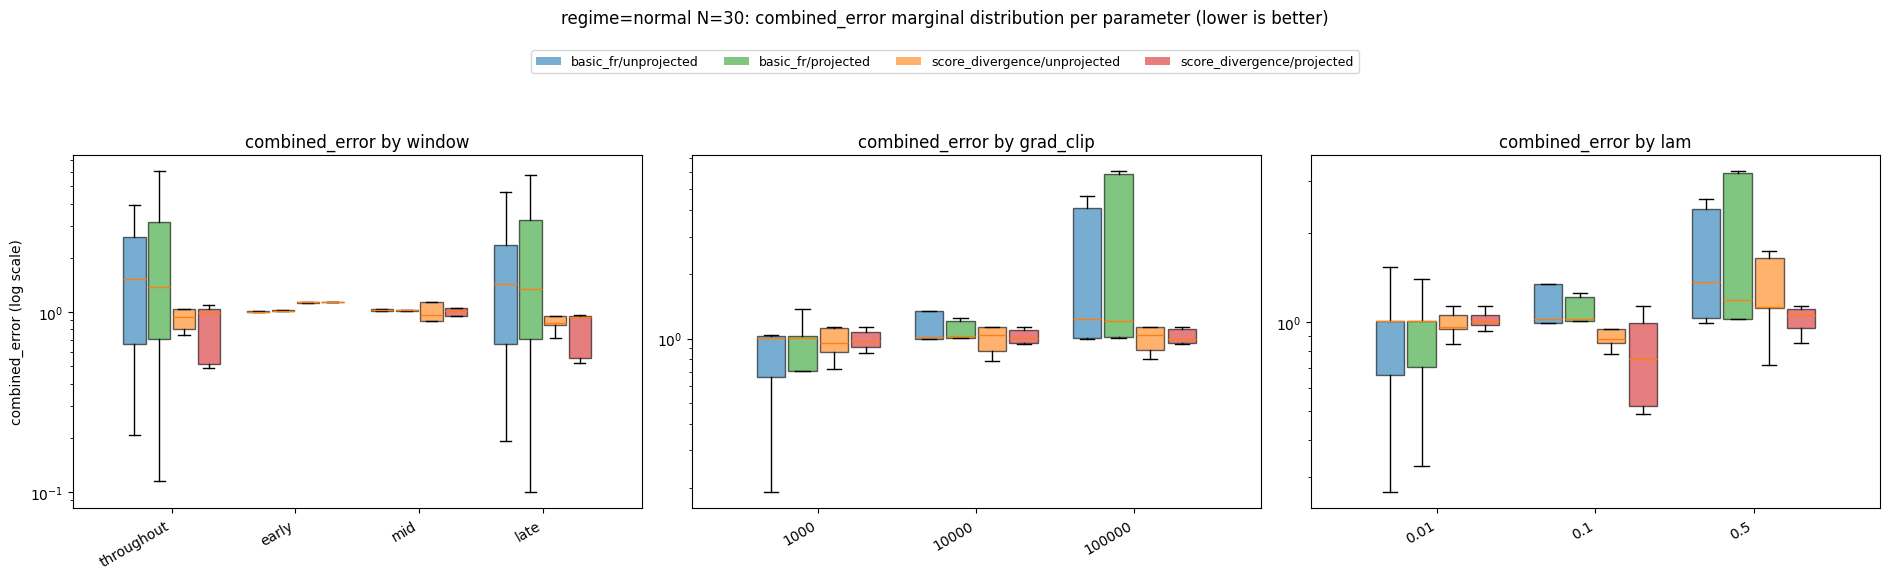

In [14]:
# Same (method, jacobian) -> color identity as the earlier diagnostic panel (blue/orange = unprojected,
# green/red = projected) so color means the same thing everywhere in this notebook.
GROUP_COLORS = {
    ("basic_fr", "unprojected"): "tab:blue",
    ("basic_fr", "projected"): "tab:green",
    ("score_divergence", "unprojected"): "tab:orange",
    ("score_divergence", "projected"): "tab:red",
}
GROUPS = list(GROUP_COLORS.keys())

def grouped_boxplot(ax, param_col, values):
    width = 0.8 / len(GROUPS)
    for gi, (method, jacobian) in enumerate(GROUPS):
        sub = guided[(guided.method == method) & (guided.jacobian == jacobian)]
        positions = [i + (gi - (len(GROUPS) - 1) / 2) * width for i in range(len(values))]
        box_data = [sub.loc[sub[param_col] == v, "combined_error"].values for v in values]
        bp = ax.boxplot(box_data, positions=positions, widths=width * 0.9, patch_artist=True, showfliers=False)
        for patch in bp["boxes"]:
            patch.set_facecolor(GROUP_COLORS[(method, jacobian)])
            patch.set_alpha(0.6)
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels([str(v) for v in values], rotation=30, ha="right")
    ax.set_yscale("log")
    ax.set_title(f"combined_error by {param_col}")

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, (param_col, values) in zip(axes, PARAM_COLS.items()):
    grouped_boxplot(ax, param_col, values)
axes[0].set_ylabel("combined_error (log scale)")

legend_handles = [plt.Rectangle((0, 0), 1, 1, facecolor=c, alpha=0.6) for c in GROUP_COLORS.values()]
legend_labels = [f"{m}/{j}" for m, j in GROUPS]
fig.legend(legend_handles, legend_labels, loc="upper center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, 1.08))
fig.suptitle(f"regime={REGIME} N={N}: combined_error marginal distribution per parameter (lower is better)", y=1.15)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/param_marginals.png", dpi=120, bbox_inches="tight")
plt.show()

## Which methods stay close to the manifold *and* improve memorization

Filter to configs with `fidelity_mse < 0.01` (stays close to the manifold) **and** `mem_ratio < 0.3` (an actual
improvement over the 0.303 unguided baseline), then rank the survivors by `combined_error`.

In [15]:
FIDELITY_MAX = baseline["fidelity_mse"] * 100 
MEM_MAX = baseline["mem_ratio"] 

qualifying = guided[(guided["fidelity_mse"] < FIDELITY_MAX) & (guided["mem_ratio"] < MEM_MAX)].sort_values("combined_error")
print(f"{len(qualifying)}/{len(guided)} configs satisfy fidelity_mse < {FIDELITY_MAX} and mem_ratio < {MEM_MAX}\n")

print("By method/jacobian, how many configs qualify (robustness of the win, not just best case):")
print(qualifying.groupby(["method", "jacobian"]).size().sort_values(ascending=False).to_string())

print("\nTop 10 qualifying configs:")
print(qualifying.head(10)[["method", "jacobian", "window", "grad_clip", "lam", "mem_ratio", "fidelity_mse", "combined_error"]].to_string(index=False))

56/144 configs satisfy fidelity_mse < 0.0818840169813484 and mem_ratio < 0.33000001311302185

By method/jacobian, how many configs qualify (robustness of the win, not just best case):
method            jacobian   
score_divergence  projected      19
                  unprojected    19
basic_fr          unprojected    12
                  projected       6

Top 10 qualifying configs:
          method    jacobian     window  grad_clip  lam  mem_ratio  fidelity_mse  combined_error
        basic_fr   projected       late     1000.0 0.10      0.030      0.000686        0.099291
        basic_fr   projected throughout     1000.0 0.10      0.035      0.000705        0.114668
        basic_fr unprojected       late     1000.0 0.10      0.060      0.000718        0.190590
        basic_fr unprojected throughout     1000.0 0.10      0.065      0.000728        0.205866
        basic_fr unprojected       late    10000.0 0.01      0.085      0.000725        0.266425
        basic_fr unprojected thr

## Scatter view: unguided vs the two best qualifying configs

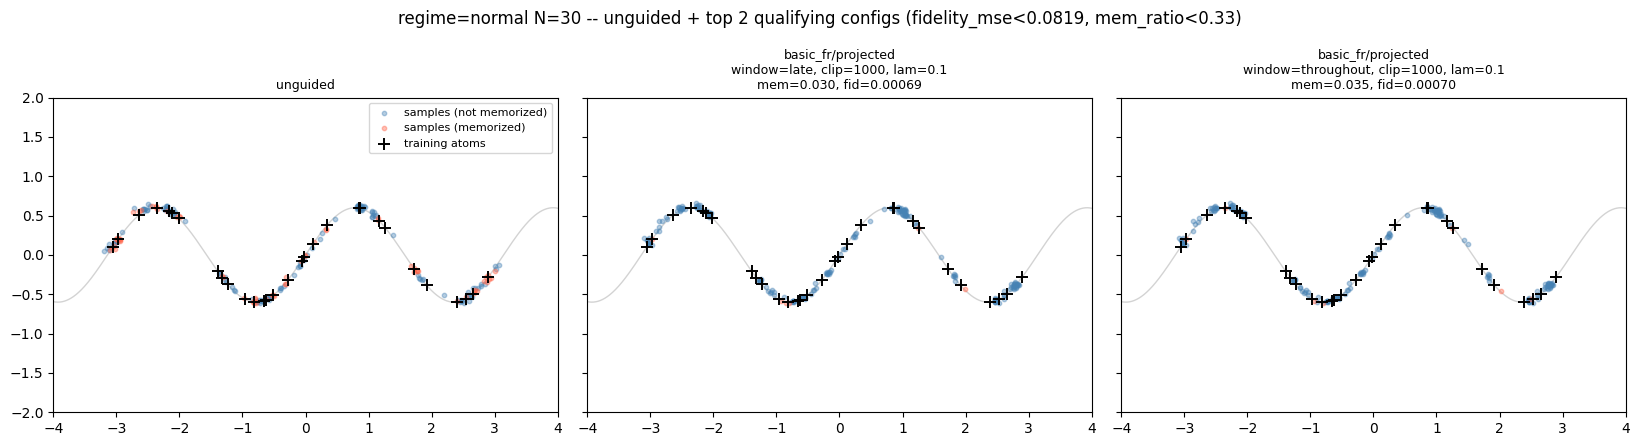

In [16]:
top2 = qualifying.head(2)
picks = [("unguided", "unprojected", "n/a", 0.0, 0.0)]
for _, r in top2.iterrows():
    picks.append((r["method"], r["jacobian"], r["window"], r["grad_clip"], r["lam"]))

fig, axes = plt.subplots(1, len(picks), figsize=(5.5 * len(picks), 4.5), sharex=True, sharey=True)
for ax, key in zip(axes, picks):
    X = samples_cache[key]
    mem = is_memorized(X, X_target, config["mem_ratio_threshold"])
    ax.plot(curve_scan[:, 0].cpu(), curve_scan[:, 1].cpu(), color="lightgray", lw=1, zorder=0)
    # color = memorized status (not just overlap density) -- same tomato/steelblue convention as the
    # "FR energy vs memorization" boxplot below, so color means the same thing across the notebook.
    # alpha still lets density show through within each group (more overlapping dots -> visibly denser).
    ax.scatter(X[~mem, 0].cpu(), X[~mem, 1].cpu(), s=10, color="steelblue", alpha=0.4,
               label="samples (not memorized)", zorder=1)
    ax.scatter(X[mem, 0].cpu(), X[mem, 1].cpu(), s=10, color="tomato", alpha=0.4,
               label="samples (memorized)", zorder=2)
    # A small "+" just pins the exact atom location -- no fill/area, so it can't be misread as a
    # memorization "zone" the way a big filled/outlined marker would (memorization is a RATIO to the
    # 2nd-nearest atom, not a distance threshold around any one atom, so no fixed-radius marker is
    # actually correct here -- see the classification check in conversation before this edit).
    ax.scatter(X_target[:, 0].cpu(), X_target[:, 1].cpu(), s=70, color="black",
               marker="+", linewidths=1.4, label="training atoms", zorder=5)
    method, jacobian, window, gc, lam = key
    if method == "unguided":
        title = "unguided"
    else:
        row = qualifying[(qualifying.method == method) & (qualifying.jacobian == jacobian) &
                          (qualifying.window == window) & (qualifying.grad_clip == gc) & (qualifying.lam == lam)].iloc[0]
        title = (f"{method}/{jacobian}\nwindow={window}, clip={gc:g}, lam={lam:g}\n"
                 f"mem={row.mem_ratio:.3f}, fid={row.fidelity_mse:.5f}")
    ax.set_title(title, fontsize=9)
    ax.set_xlim(-4, 4); ax.set_ylim(-2, 2)
axes[0].legend(fontsize=8)
plt.suptitle(f"regime={REGIME} N={N} -- unguided + top 2 qualifying configs (fidelity_mse<{np.round(FIDELITY_MAX, 4)}, mem_ratio<{np.round(MEM_MAX, 3)})")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fr_comparison.png", dpi=120); plt.show()

## Fisher-Rao energy at the final point vs. memorization

Descriptive check: does the k-NN FR energy `I(y)` (evaluated at each sample's own final position, at the
temperature the sampler used in its last step) actually separate memorized from non-memorized samples? If FR
energy is a meaningful "closeness to a memorized mode" signal, memorized samples should sit at systematically
lower `I(y)` than non-memorized ones -- and guidance should be pushing samples away from the low-energy
(memorized) region.

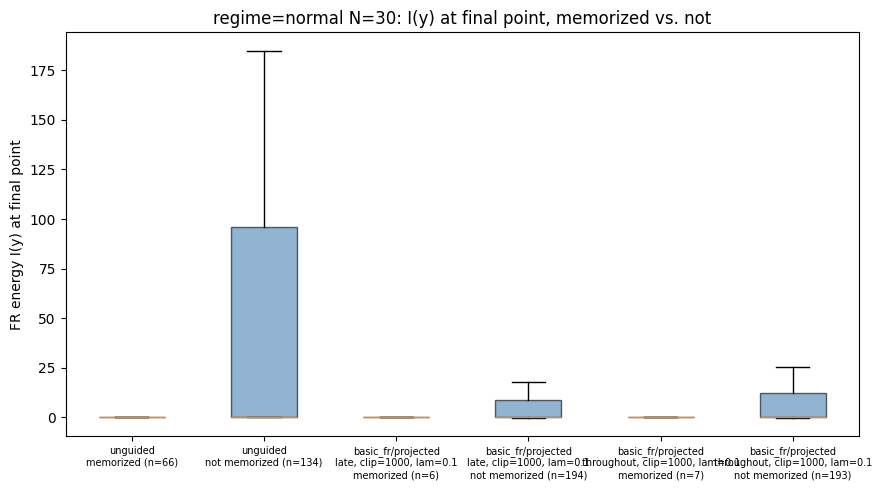

In [17]:
_sigma2_final_scalar = sigma2(torch.tensor(dt)).item()

def energy_at_final_point(X):
    # I(y) at the sampler's final temperature (t=dt, the last step actually taken), independent
    # of whichever method/window/lam produced X -- a fixed yardstick for comparing conditions.
    sigma2_final = torch.full((X.shape[0],), _sigma2_final_scalar)
    neighbors, _ = basic_fr.ann_query(index, X, config["k_neighbors"])
    I, _, _ = basic_fr.fisher_rao_energy(X, neighbors, sigma2_final)
    return I

picks_energy = [("unguided", "unprojected", "n/a", 0.0, 0.0)] + [
    (r["method"], r["jacobian"], r["window"], r["grad_clip"], r["lam"]) for _, r in top2.iterrows()
]

box_data, box_labels, box_colors = [], [], []
for key in picks_energy:
    X = samples_cache[key]
    mem = is_memorized(X, X_target, config["mem_ratio_threshold"])
    I = energy_at_final_point(X)
    label = "unguided" if key[0] == "unguided" else f"{key[0]}/{key[1]}\n{key[2]}, clip={key[3]:g}, lam={key[4]:g}"
    box_data += [I[mem].numpy(), I[~mem].numpy()]
    box_labels += [f"{label}\nmemorized (n={int(mem.sum())})", f"{label}\nnot memorized (n={int((~mem).sum())})"]
    box_colors += ["tomato", "steelblue"]

fig, ax = plt.subplots(figsize=(3 * len(picks_energy), 5))
bp = ax.boxplot(box_data, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_xticks(range(1, len(box_labels) + 1))
ax.set_xticklabels(box_labels, fontsize=7)
ax.set_ylabel("FR energy I(y) at final point")
ax.set_title(f"regime={REGIME} N={N}: I(y) at final point, memorized vs. not")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fr_energy_vs_memorization.png", dpi=120); plt.show()

## Full 2D score field: heatmaps + 3D surface

Same empirical-vs-learned comparison, but evaluated on a full `(x, y)` grid instead of 1D slices, plotting
`-log10(||score||)` (not `+log10`): `||score||` is near-zero right at a data concentration (each Gaussian
component's own mean is a fixed point of that component's drift) and large in between/away from data, so
`+log10(||score||)` puts concentrations in *valleys* and the empty-space "collapse" region in *peaks* --
backwards from what we want to look at. Negating flips this: concentrations become tall peaks, empty space
drops low. Heatmaps for `early`/`mid`/`late` (empirical top row, learned bottom), manifold curve + atoms
overlaid; then one 3D surface at `late` (smallest `sigma_t`, sharpest peaks), empirical vs. learned side by
side.

**Third `guided` panel**: the "new" score under guidance, `score(z_t) + lam*grad_guidance(z_t)` -- deliberately
*not* multiplied by `g(t)` (`step_scale_fn`), same reasoning as the diagnostic panel's `||score||` vs `||grad||`
comparison (the `beta(t)*dt` prefactor is shared by both terms in the real update, so this ratio is what
actually determines the guided drift's direction/scale). Uses the single best qualifying config
(`top2.iloc[0]`)'s `(method, jacobian, grad_clip, lam)`, applied via the same `make_guidance_fn`/
`driver.guidance_grad`/`driver.projected_guidance_grad` machinery the real sampler uses -- not a separate
reimplementation -- so this is exactly the score field guidance would produce at that instant, not an
approximation of it.

In [18]:

def mixture_score(points, atoms, t):
    t_scalar = torch.tensor(t)
    a = alpha_bar(t_scalar)
    var = (1 - a).clamp(min=1e-6)
    means = atoms * a.sqrt()                                    # [N, 2]
    diff = points[:, None, :] - means[None, :, :]                # [B, N, 2]
    logw = -(diff ** 2).sum(-1) / (2 * var)                       # [B, N]
    w = torch.softmax(logw, dim=1)
    return (w[:, :, None] * (means[None, :, :] - points[:, None, :])).sum(1) / var

def learned_score(points, t):
    t_vec = torch.full((points.shape[0],), t, device=device)
    with torch.no_grad():
        eps_hat = net(points, t_vec)
    return -eps_hat / sigma2(t_vec)[:, None].sqrt()

def guided_score(points, t, guidance_fn, lam):
    # "new" score under guidance = score(points, t) + lam * grad_guidance(points, t) -- NOT multiplied
    # by g(t)/step_scale_fn, see this section's markdown for why. guidance_fn is one of make_guidance_fn's
    # closures (driver.guidance_grad / driver.projected_guidance_grad under the hood), treating `points`
    # as z_t exactly like learned_score already does -- so this is the real guidance mechanism, not a
    # reimplementation of it. Sets t_vec_holder["t"] since guidance_fn/y_fn/energy_fn all read it.
    t_vec_holder["t"] = torch.full((points.shape[0],), t, device=device)
    base = learned_score(points, t)
    grad, _, _ = guidance_fn(points)
    return base + lam * grad


guided score uses best qualifying config: method=basic_fr jacobian=projected grad_clip=1000 lam=0.1


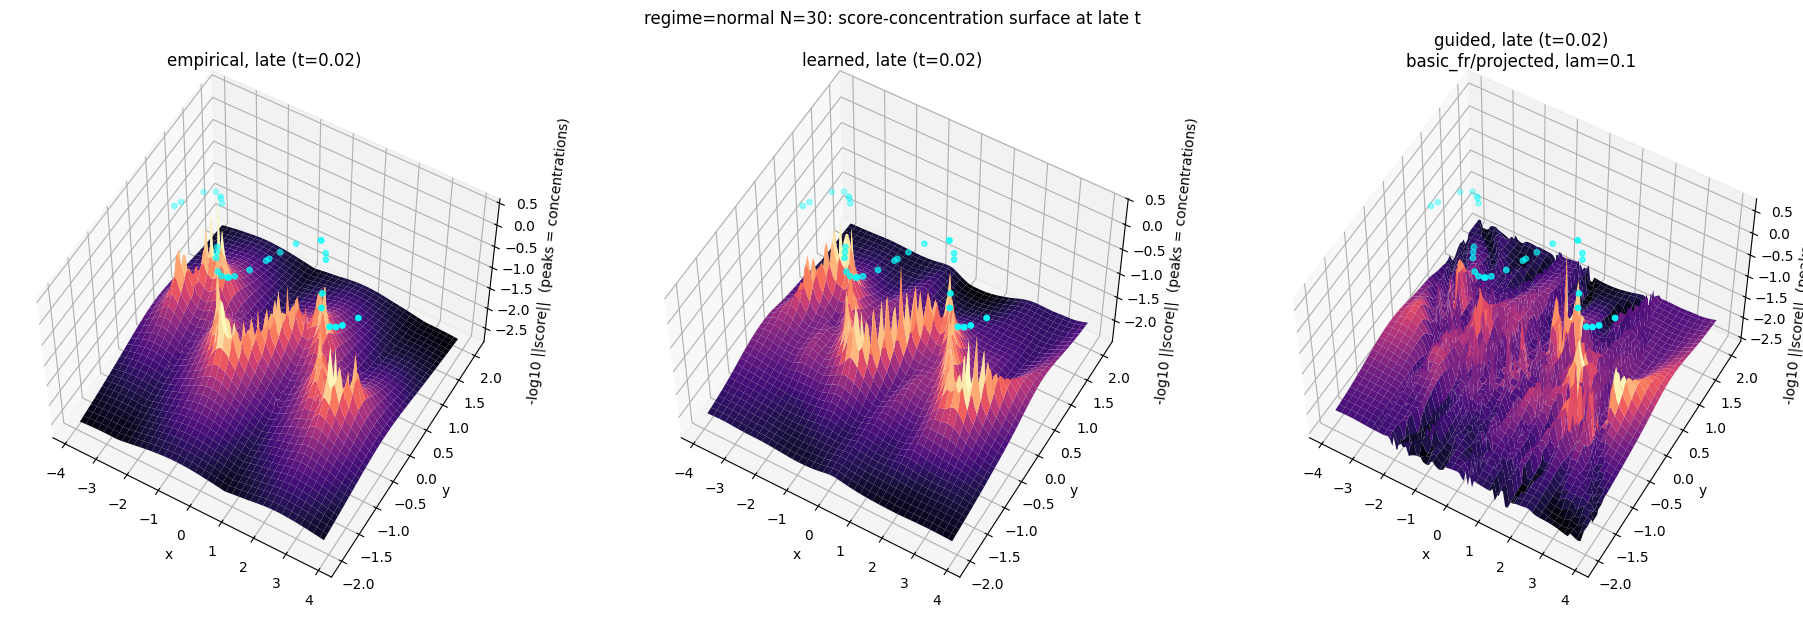

In [19]:
from mpl_toolkits.mplot3d import Axes3D

T_POINTS = {"early": 0.9, "mid": 0.3, "late": 0.02}   # early/mid/late = stage of the REVERSE (generation)
                                                       # process, matching `windows` above: early=noisy
                                                       # (high t), late=clean (low t) -- NOT forward-diffusion
                                                       # time. At high t the diffused mixture collapses onto
                                                       # a single Gaussian near the origin regardless of N or
                                                       # atom positions (sqrt(alpha_bar_t)*atom -> 0) -- that's
                                                       # the VP-SDE correctly converging to its N(0,I) prior,
                                                       # not a bug. Atom-level structure only survives at low t.
SLICE_N = 400


GRID_N = 120
SCORE_EPS = 1e-3
gx = torch.linspace(-1.2 * train_config["u_range"], 1.2 * train_config["u_range"], GRID_N)
gy = torch.linspace(-2.0, 2.0, GRID_N)
GX, GY = torch.meshgrid(gx, gy, indexing="xy")
grid_points = torch.stack([GX.reshape(-1), GY.reshape(-1)], dim=-1)

best_row = top2.iloc[0]
best_guidance_fn = make_guidance_fn(best_row["method"], best_row["jacobian"], best_row["grad_clip"])
best_lam = best_row["lam"]
print(f"guided score uses best qualifying config: method={best_row['method']} jacobian={best_row['jacobian']} "
      f"grad_clip={best_row['grad_clip']:g} lam={best_lam:g}")

grid_neg_log = {}   # (kind, t_name) -> -log10(||score||), [GRID_N, GRID_N] -- peaks = concentrations
for t_name, t_val in T_POINTS.items():
    emp = mixture_score(grid_points, X_target, t_val).norm(dim=-1).reshape(GRID_N, GRID_N)
    learn = learned_score(grid_points, t_val).norm(dim=-1).reshape(GRID_N, GRID_N)
    guided = guided_score(grid_points, t_val, best_guidance_fn, best_lam).norm(dim=-1).reshape(GRID_N, GRID_N)
    grid_neg_log[("empirical", t_name)] = -torch.log10(emp.clamp(min=SCORE_EPS))
    grid_neg_log[("learned", t_name)] = -torch.log10(learn.clamp(min=SCORE_EPS))
    grid_neg_log[("guided", t_name)] = -torch.log10(guided.clamp(min=SCORE_EPS))

fig = plt.figure(figsize=(19, 6))
for i, kind in enumerate(["empirical", "learned", "guided"]):
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    Z = grid_neg_log[(kind, "late")]
    ax.plot_surface(GX.numpy(), GY.numpy(), Z.numpy(), cmap="magma", linewidth=0, antialiased=True)
    ax.scatter(X_target[:, 0].cpu(), X_target[:, 1].cpu(), torch.full((N,), Z.max().item()), color="cyan", s=15)
    ax.view_init(elev=55, azim=-60)   # steeper, more top-down angle -- default (elev=30) makes tall,
                                       # narrow peaks read as a descending ramp instead of spikes
    title = f"{kind}, late (t={T_POINTS['late']})"
    if kind == "guided":
        title += f"\n{best_row['method']}/{best_row['jacobian']}, lam={best_lam:g}"
    ax.set_title(title)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("-log10 ||score||  (peaks = concentrations)")
fig.suptitle(f"regime={REGIME} N={N}: score-concentration surface at late t")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/score_field_surface_late.png", dpi=120, bbox_inches="tight")
plt.show()